# VAC Forming  Scrap Recommendation Engine

When a scrap event is detected on the VAC forming line, this engine looks at the machine parameters that were recorded for that part, compares them to what "normal good production" looks like *on the same tool*, and tells the operator which parameters were abnormal and in which direction.




---
## 1. Load & Prepare Data

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# ── Load ──
process_raw = pd.read_excel('Book3.xlsx', sheet_name='Process Data')
scrap_raw   = pd.read_excel('Book3.xlsx', sheet_name='Scrap')

# ── Parse the 40 machine parameters from DS1/DS2/DS3 ──
def parse_params(val):
    pairs = {}
    if pd.notna(val):
        for item in str(val).split(','):
            if ':' in item:
                k, v = item.rsplit(':', 1)
                try:
                    pairs[k.strip()] = float(v.strip())
                except ValueError:
                    pass
    return pairs

ds1 = process_raw['DS1'].apply(parse_params).apply(pd.Series)
ds2 = process_raw['DS2'].apply(parse_params).apply(pd.Series)
ds3 = process_raw['DS3'].apply(parse_params).apply(pd.Series)

df = pd.concat([process_raw[['ID', 'part_desc', 'built_time']], ds1, ds2, ds3], axis=1)

# ── Merge scrap labels ──
df = df.merge(scrap_raw[['wip_part_id', 'description']],
              left_on='ID', right_on='wip_part_id', how='left')
df['description'] = df['description'].fillna('Good')
df.drop(columns=['wip_part_id'], inplace=True)

# ── Define scope ──
PROCESS_DEFECTS = [
    'Low Glue/Read Thru/Impression', 'Wrinkle', 'Dent', 'Bumps / lumps',
    'Out of dimension', 'Burnt Carpet / Vynil', 'Water stain',
    'Glue bleed thru', 'Short material / shot'
]
df['is_process_scrap'] = df['description'].isin(PROCESS_DEFECTS)

print(f"Total parts:          {len(df):,}")
print(f"Good parts:           {(df['description']=='Good').sum():,}")
print(f"Process scrap:        {df['is_process_scrap'].sum()}")
print(f"Tools in data:        {sorted(df['Tool Number'].unique())}")

Total parts:          4,283
Good parts:           3,934
Process scrap:        314
Tools in data:        [np.float64(1.0), np.float64(2.0), np.float64(8.0)]


---
## 2. Define Process Sections

Each machine parameter belongs to a physical section of the VAC forming line. Grouping recommendations by section helps the operator know *where* to look.

In [15]:
# Which process section does each parameter belong to?
PARAM_TO_SECTION = {
    # ── Roll Coating ── (glue application)
    'Roller Gap LH':       'Roll Coating',
    'Roller Gap RH':       'Roll Coating',
    'Glue Temp':           'Roll Coating',
    'Pick Material Pos':   'Roll Coating',

    # ── Grippers & Clamp Frame ── (vinyl positioning & stretching)
    'Pos Vinyl N Length':          'Clamp Frame',
    'Pos Vinyl N Width':           'Clamp Frame',
    'Pos Vinyl S Length':          'Clamp Frame',
    'Pos Vinyl S Width':           'Clamp Frame',
    'Stetch Length Pick Up':       'Clamp Frame',
    'Stetch Length Stretch 1':     'Clamp Frame',
    'Stetch Length Stretch 2':     'Clamp Frame',
    'Stetch Length Stretch 3':     'Clamp Frame',
    'Stetch Length Form':          'Clamp Frame',
    'Stretch Cross Pick Up':       'Clamp Frame',
    'Stretch Cross Stretch 1':     'Clamp Frame',
    'Stretch Cross Stretch 2':     'Clamp Frame',
    'Stretch Cross Stretch 3':     'Clamp Frame',
    'Stretch Cross Form':          'Clamp Frame',
    'Top Tool Pos Close':          'Clamp Frame',

    # ── Oven ── (heating)
    'Temp. THT at Trigger':            'Oven',
    'Temp. BHT at Trigger':            'Oven',
    'Temp Z1':                         'Oven',
    'Temp Z2':                         'Oven',
    'Temp Z3':                         'Oven',
    'Temp Z4':                         'Oven',
    'heating time (tens of seconds)':  'Oven',
    'Capacity THT':                    'Oven',
    'Capacity BHT':                    'Oven',

    # ── Vacuum Press ──
    'Vacuum Time Tool Cavity A':       'Vacuum Press',
    'Vacuum Time Tool Cavity B':       'Vacuum Press',
    'Graining Vacuum TTF Cavity 1':    'Vacuum Press',
    'Graining Vacuum TTF Cavity 2':    'Vacuum Press',

    # ── Machine / Cycle ──
    'Machine Cycle Time':     'Machine',
    'Pyro Clean':             'Machine',
    'BT Circuit 1 Temp':      'Machine',
    'BT Circuit 2 Temp':      'Machine',
    'TTF Circuit 1 Temp':     'Machine',
    'TTF Circuit 2 Temp':     'Machine',
    'Time Feed to Vacuum 1':  'Machine',
    'Tool Number':            'Machine',
}

# Friendly short names for display
PARAM_SHORT = {
    'Temp. THT at Trigger': 'Top Heater Temp (THT)',
    'Temp. BHT at Trigger': 'Bottom Heater Temp (BHT)',
    'heating time (tens of seconds)': 'Heating Time',
    'Stetch Length Pick Up': 'Stretch Length - Pick Up',
    'Stetch Length Stretch 1': 'Stretch Length - Stage 1',
    'Stetch Length Stretch 2': 'Stretch Length - Stage 2',
    'Stetch Length Stretch 3': 'Stretch Length - Stage 3',
    'Stetch Length Form': 'Stretch Length - Form',
    'Graining Vacuum TTF Cavity 1': 'Graining Vacuum Cav. 1',
    'Graining Vacuum TTF Cavity 2': 'Graining Vacuum Cav. 2',
}

ALL_PARAMS = [p for p in PARAM_TO_SECTION.keys() if p != 'Tool Number']

# Section display order
SECTION_ORDER = ['Roll Coating', 'Clamp Frame', 'Oven', 'Vacuum Press', 'Machine']

print(f"Tracking {len(ALL_PARAMS)} parameters across {len(SECTION_ORDER)} sections.")

Tracking 39 parameters across 5 sections.


---
##  Build Tool-Specific Baselines

This is the key step. Instead of computing one global "normal" across all tools, we compute **separate baselines for each tool**. This is critical because:

| Parameter | Tool 1 | Tool 2 | Tool 8 |
|---|---|---|---|
| Roller Gap LH | ~7 | ~21 | ~20 |
| Roller Gap RH | ~4 | ~20 | ~18 |
| Glue Temp | ~146 | ~156 | ~156 |
| Stretch Cross Form | ~9,797 | ~4,856 | ~4,880 |

If we mixed these together, a Roller Gap of 7 on Tool 1 would look "low" globally but is actually the **normal operating point** for that tool. Tool-specific baselines avoid this problem.

In [16]:
good = df[df['description'] == 'Good'].copy()

# ── Clean Machine Cycle Time ──
# 9999 is a sentinel / timeout value — not a real cycle time.
# We exclude it when computing baselines so it doesn't inflate the mean/std.
SENTINEL_VALUE = 9999

# ── Build baselines ──
# For each (tool, parameter): store (mean, std) from good parts only.
# Skip parameters where std is effectively 0 — they're constant machine settings
# for that tool and can't meaningfully deviate.

MIN_STD = 1.0        # below this, parameter is considered constant for that tool
MIN_SAMPLES = 20     # need enough good parts to trust the baseline

baselines = {}  # baselines[(tool, param)] = {'mean': ..., 'std': ...}
skipped = []    # track what we skip and why

for tool in sorted(good['Tool Number'].unique()):
    tool_good = good[good['Tool Number'] == tool]
    baselines[tool] = {}
    
    for param in ALL_PARAMS:
        if param not in tool_good.columns:
            continue
        
        vals = tool_good[param].dropna()
        
        # Filter sentinel values for Machine Cycle Time
        if param == 'Machine Cycle Time':
            vals = vals[vals < SENTINEL_VALUE]
        
        if len(vals) < MIN_SAMPLES:
            skipped.append((tool, param, 'too few samples'))
            continue
        
        mean_val = vals.mean()
        std_val = vals.std()
        
        if std_val < MIN_STD:
            skipped.append((tool, param, f'constant (std={std_val:.2f})'))
            continue
        
        baselines[tool][param] = {
            'mean': mean_val,
            'std': std_val,
            'p5': np.percentile(vals, 5),
            'p95': np.percentile(vals, 95)
        }

# Summary
print("Baselines built:\n")
for tool in sorted(baselines.keys()):
    n_good = len(good[good['Tool Number'] == tool])
    n_params = len(baselines[tool])
    print(f"  Tool {int(tool):>2}: {n_good:,} good parts, {n_params} trackable parameters")

print(f"\nSkipped {len(skipped)} (tool, param) combinations (constant or insufficient data).")
print("Examples of skipped:")
for tool, param, reason in skipped[:8]:
    print(f"  Tool {int(tool)} / {param}: {reason}")

Baselines built:

  Tool  1: 1,190 good parts, 30 trackable parameters
  Tool  2: 2,309 good parts, 28 trackable parameters
  Tool  8: 435 good parts, 19 trackable parameters

Skipped 40 (tool, param) combinations (constant or insufficient data).
Examples of skipped:
  Tool 1 / Roller Gap RH: constant (std=0.79)
  Tool 1 / Stretch Cross Stretch 1: constant (std=0.00)
  Tool 1 / Stretch Cross Stretch 2: constant (std=0.00)
  Tool 1 / Graining Vacuum TTF Cavity 1: constant (std=0.46)
  Tool 1 / Graining Vacuum TTF Cavity 2: constant (std=0.05)
  Tool 1 / BT Circuit 1 Temp: constant (std=0.94)
  Tool 1 / BT Circuit 2 Temp: constant (std=0.77)
  Tool 1 / TTF Circuit 1 Temp: constant (std=0.00)


### this shows why tool-specific baselines are essential.

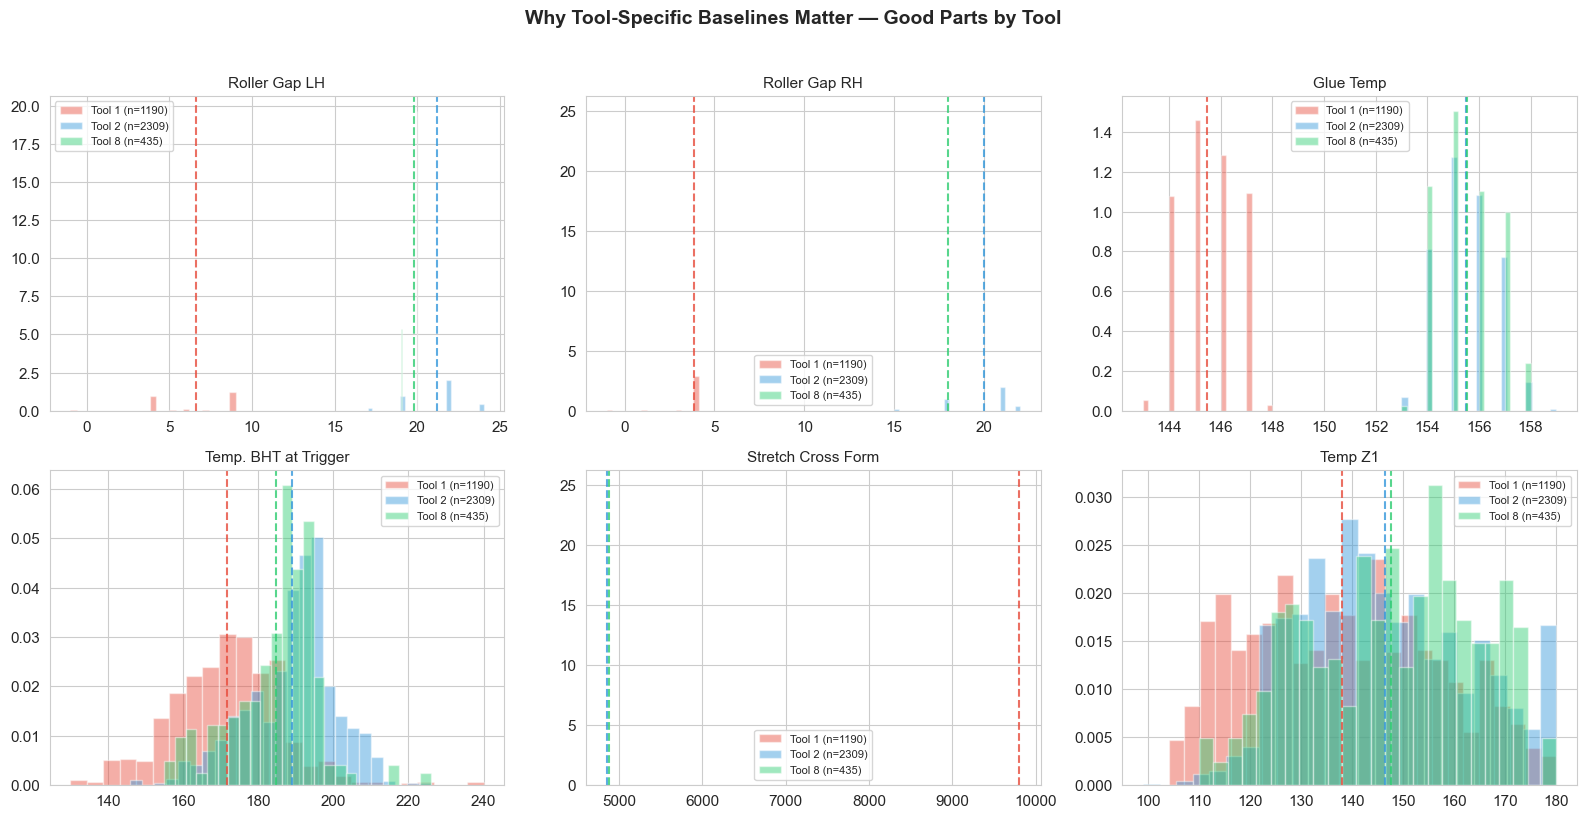

In [17]:
show_params = ['Roller Gap LH', 'Roller Gap RH', 'Glue Temp',
               'Temp. BHT at Trigger', 'Stretch Cross Form', 'Temp Z1']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
tool_colors = {1.0: '#e74c3c', 2.0: '#3498db', 8.0: '#2ecc71'}

for ax, param in zip(axes.flat, show_params):
    for tool, color in tool_colors.items():
        vals = good[good['Tool Number'] == tool][param].dropna()
        if len(vals) > 10:
            ax.hist(vals, bins=25, alpha=0.45, color=color,
                    label=f'Tool {int(tool)} (n={len(vals)})', density=True)
            ax.axvline(vals.mean(), color=color, linestyle='--', linewidth=1.5, alpha=0.8)
    ax.set_title(param, fontsize=11)
    ax.legend(fontsize=8)

fig.suptitle('Why Tool-Specific Baselines Matter — Good Parts by Tool',
             fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('tool_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## The Deviation Score Engine

This is the core of the recommendation system. For a given scrap part, it:

1. Looks up which **tool** was used
2. For each parameter, computes: **deviation score = (actual value - normal mean) / normal std**
3. Filters to only parameters with **|score| > 1** (more than 1 standard deviation from normal)
4. Ranks by severity and groups by process section
5. Outputs direction-only recommendations

In [18]:
def compute_deviation_scores(part_row):
    """
    Given a single part's data (a row from the dataframe),
    compute the deviation score for every trackable parameter
    against the tool-specific baseline.
    
    Returns a list of dicts, sorted by |deviation| descending.
    """
    tool = part_row['Tool Number']
    
    if tool not in baselines:
        return []
    
    tool_bl = baselines[tool]
    scores = []
    
    for param, bl in tool_bl.items():
        val = part_row.get(param, np.nan)
        if pd.isna(val):
            continue
        
        # Skip sentinel Machine Cycle Time values
        if param == 'Machine Cycle Time' and val >= SENTINEL_VALUE:
            continue
        
        z = (val - bl['mean']) / bl['std']
        
        scores.append({
            'parameter': param,
            'display_name': PARAM_SHORT.get(param, param),
            'section': PARAM_TO_SECTION.get(param, 'Other'),
            'deviation_score': round(z, 2),
            'abs_deviation': round(abs(z), 2),
            'direction': 'HIGH' if z > 0 else 'LOW',
        })
    
    # Sort by absolute deviation (biggest problems first)
    scores.sort(key=lambda x: x['abs_deviation'], reverse=True)
    return scores


def classify_severity(abs_z):
    """Convert absolute z-score to a human-readable severity level."""
    if abs_z >= 3.0:
        return 'CRITICAL'    # way outside normal range
    elif abs_z >= 2.0:
        return 'HIGH'        # clearly abnormal
    elif abs_z >= 1.0:
        return 'MODERATE'    # noticeable deviation
    else:
        return 'NORMAL'      # within expected range


def generate_recommendations(part_row, min_abs_z=1.0, max_recs=10):
    """
    Main recommendation function.
    
    Takes a scrapped part's data, returns:
    - A list of recommendations (only parameters deviating by more than min_abs_z)
    - Grouped by process section
    - Direction only (no exact target values)
    
    Args:
        part_row:   A row from the dataframe (one part)
        min_abs_z:  Minimum |z-score| to report (default 1.0 = 1 std dev)
        max_recs:   Maximum number of recommendations to return
    """
    tool = part_row['Tool Number']
    defect = part_row.get('description', 'Unknown')
    part = part_row.get('part_desc', 'Unknown')
    part_id = part_row.get('ID', 'Unknown')
    
    # Get all deviation scores
    all_scores = compute_deviation_scores(part_row)
    
    # Filter to significant deviations only
    significant = [s for s in all_scores if s['abs_deviation'] >= min_abs_z]
    significant = significant[:max_recs]  # cap it
    
    # Add severity labels
    for s in significant:
        s['severity'] = classify_severity(s['abs_deviation'])
    
    return {
        'part_id': part_id,
        'part_desc': part,
        'defect': defect,
        'tool': int(tool),
        'time': str(part_row.get('built_time', '')),
        'recommendations': significant,
        'total_deviating': len([s for s in all_scores if s['abs_deviation'] >= min_abs_z]),
    }


def display_recommendations(result):
    """
    Pretty-print the recommendation output.
    Grouped by section, sorted by severity.
    """
    recs = result['recommendations']
    
    print(f"{'='*80}")
    print(f"  SCRAP DETECTED: {result['defect']}")
    print(f"  Part: {result['part_desc']}  |  Tool: {result['tool']}  |  ID: {result['part_id']}")
    print(f"  Time: {result['time']}")
    print(f"{'='*80}")
    
    if not recs:
        print("\n  No significant parameter deviations detected.")
        print("  This scrap event may be due to factors outside the tracked parameters")
        print("  (e.g., material quality, tool wear, environmental conditions).")
        return
    
    print(f"\n  {len(recs)} parameter(s) deviated from normal (out of {result['total_deviating']} total):\n")
    
    # Group by section in order
    for section in SECTION_ORDER:
        sec_recs = [r for r in recs if r['section'] == section]
        if not sec_recs:
            continue
        
        print(f"  [{section}]")
        for r in sec_recs:
            sev = r['severity']
            arrow = 'HIGH  ^' if r['direction'] == 'HIGH' else 'LOW   v'
            name = r['display_name']
            z = r['deviation_score']
            
            # Build the recommendation text
            if r['direction'] == 'HIGH':
                action = 'Consider REDUCING'
            else:
                action = 'Consider INCREASING'
            
            print(f"    [{sev:<8}]  {name:<35} running {arrow}  (deviation: {z:+.1f})  -->  {action}")
        print()
    
    print(f"  {'─'*70}")
    print(f"  Deviation score meaning: +/-1 = noticeable, +/-2 = clearly abnormal, +/-3 = extreme")


print("Recommendation engine ready.")

Recommendation engine ready.


---
##  Step-by-Step Walkthrough: How a Single Recommendation is Generated


In [19]:
# Pick a real Low Glue scrap event from Tool 1
example = df[(df['description'] == 'Low Glue/Read Thru/Impression') & (df['Tool Number'] == 1.0)].iloc[0]

print("STEP 1: A scrap event is detected")
print(f"  Part ID:   {example['ID']}")
print(f"  Part:      {example['part_desc']}")
print(f"  Defect:    {example['description']}")
print(f"  Tool:      {int(example['Tool Number'])}")
print()

print("STEP 2: Look up Tool 1's baseline (what 'normal good' looks like)")
print(f"  Tool 1 baseline has {len(baselines[1.0])} trackable parameters.")
print(f"  A few examples:")
for p in ['Glue Temp', 'Temp. BHT at Trigger', 'Roller Gap LH', 'heating time (tens of seconds)']:
    if p in baselines[1.0]:
        bl = baselines[1.0][p]
        print(f"    {p:<35}  normal mean: {bl['mean']:.1f}  spread (std): {bl['std']:.1f}")
print()

print("STEP 3: Compute deviation scores for this part")
print(f"  Formula: score = (actual value - normal mean) / normal std")
print()
scores = compute_deviation_scores(example)
print(f"  {'Parameter':<35} {'Actual':>8} {'Normal':>8} {'Std':>6} {'Score':>7}  Direction")
print(f"  {'─'*85}")
for s in scores[:12]:
    p = s['parameter']
    bl = baselines[1.0][p]
    actual = example[p]
    arrow = '^' if s['direction'] == 'HIGH' else 'v'
    marker = ' <<<' if s['abs_deviation'] >= 1.0 else ''
    print(f"  {p:<35} {actual:>8.1f} {bl['mean']:>8.1f} {bl['std']:>6.1f} {s['deviation_score']:>+7.2f}  {s['direction']}{marker}")
print(f"  ...({len(scores)} parameters total)")
print()

print("STEP 4: Filter to significant deviations (|score| >= 1.0)")
sig = [s for s in scores if s['abs_deviation'] >= 1.0]
print(f"  {len(sig)} parameters are significantly deviating.")
print()

print("STEP 5: Generate recommendations")
print()
result = generate_recommendations(example)
display_recommendations(result)

STEP 1: A scrap event is detected
  Part ID:   8716551
  Part:      RR MAP POCKET WHITE
  Defect:    Low Glue/Read Thru/Impression
  Tool:      1

STEP 2: Look up Tool 1's baseline (what 'normal good' looks like)
  Tool 1 baseline has 30 trackable parameters.
  A few examples:
    Glue Temp                            normal mean: 145.5  spread (std): 1.1
    Temp. BHT at Trigger                 normal mean: 171.8  spread (std): 14.5
    Roller Gap LH                        normal mean: 6.6  spread (std): 2.5
    heating time (tens of seconds)       normal mean: 458.7  spread (std): 79.9

STEP 3: Compute deviation scores for this part
  Formula: score = (actual value - normal mean) / normal std

  Parameter                             Actual   Normal    Std   Score  Direction
  ─────────────────────────────────────────────────────────────────────────────────────
  Roller Gap LH                           -1.0      6.6    2.5   -3.00  LOW <<<
  Capacity BHT                            35.0

---
##  test :Recommendations for Every Defect Type


In [20]:
demo_defects = [
    'Low Glue/Read Thru/Impression',
    'Wrinkle',
    'Dent',
    'Bumps / lumps',
    'Out of dimension',
    'Burnt Carpet / Vynil',
]

for defect in demo_defects:
    subset = df[df['description'] == defect]
    if len(subset) == 0:
        continue
    
    # Pick the first example
    sample = subset.iloc[0]
    result = generate_recommendations(sample)
    display_recommendations(result)
    print("\n")

  SCRAP DETECTED: Low Glue/Read Thru/Impression
  Part: GB OUTER LHD WHITE  |  Tool: 2  |  ID: 8750202
  Time: 2026-03-05 10:25:25.587000

  10 parameter(s) deviated from normal (out of 14 total):

  [Clamp Frame]
    [HIGH    ]  Stretch Cross Stretch 3             running LOW   v  (deviation: -2.1)  -->  Consider INCREASING
    [HIGH    ]  Stretch Cross Form                  running HIGH  ^  (deviation: +2.0)  -->  Consider REDUCING
    [MODERATE]  Top Tool Pos Close                  running HIGH  ^  (deviation: +2.0)  -->  Consider REDUCING
    [MODERATE]  Stretch Cross Pick Up               running LOW   v  (deviation: -1.9)  -->  Consider INCREASING
    [MODERATE]  Stretch Cross Stretch 1             running LOW   v  (deviation: -1.9)  -->  Consider INCREASING

  [Oven]
    [CRITICAL]  Capacity THT                        running HIGH  ^  (deviation: +3.0)  -->  Consider REDUCING
    [HIGH    ]  Bottom Heater Temp (BHT)            running LOW   v  (deviation: -3.0)  -->  Consider IN

---
## aggregate Analysis: 

Instead of looking at one part at a time, this sees which parameters deviate most *on average* for each defect type.

In [21]:
# Run engine on ALL scrap events and collect deviation scores
all_deviations = []

scrap_df = df[df['is_process_scrap']].copy()

for idx, row in scrap_df.iterrows():
    scores = compute_deviation_scores(row)
    for s in scores:
        s['defect'] = row['description']
        s['tool'] = row['Tool Number']
        all_deviations.append(s)

dev_df = pd.DataFrame(all_deviations)
print(f"Computed {len(dev_df):,} deviation scores across {len(scrap_df)} scrap events.")

Computed 9,093 deviation scores across 314 scrap events.


In [22]:
# For each defect type: what are the top deviating parameters on average?
print("TYPICAL DEVIATION PATTERNS PER DEFECT")
print("(Average deviation score across all scrap events of that type)\n")
print("Negative = parameter is running LOW.  Positive = parameter is running HIGH.")
print("Bigger magnitude = more abnormal.\n")

for defect in demo_defects:
    defect_devs = dev_df[dev_df['defect'] == defect]
    n_events = len(scrap_df[scrap_df['description'] == defect])
    
    if len(defect_devs) == 0:
        continue
    
    # Average deviation per parameter
    avg = defect_devs.groupby('parameter')['deviation_score'].agg(['mean', 'std', 'count'])
    avg['abs_mean'] = avg['mean'].abs()
    avg = avg.sort_values('abs_mean', ascending=False)
    
    print(f"{'='*80}")
    print(f"  {defect} ({n_events} events)")
    print(f"{'='*80}")
    print(f"  {'Parameter':<40} {'Section':<15} {'Avg Score':>10} {'Direction':>10}")
    print(f"  {'─'*78}")
    
    shown = 0
    for param, row in avg.iterrows():
        if row['abs_mean'] < 0.3:  # skip negligible
            continue
        section = PARAM_TO_SECTION.get(param, '?')
        direction = 'HIGH  ^' if row['mean'] > 0 else 'LOW   v'
        bar = '|' + '=' * int(min(row['abs_mean'] * 5, 25))
        print(f"  {param:<40} {section:<15} {row['mean']:>+10.2f} {direction:>10}  {bar}")
        shown += 1
        if shown >= 12:
            break
    print()

TYPICAL DEVIATION PATTERNS PER DEFECT
(Average deviation score across all scrap events of that type)

Negative = parameter is running LOW.  Positive = parameter is running HIGH.
Bigger magnitude = more abnormal.

  Low Glue/Read Thru/Impression (130 events)
  Parameter                                Section          Avg Score  Direction
  ──────────────────────────────────────────────────────────────────────────────
  Pos Vinyl S Length                       Clamp Frame          -1.74    LOW   v  |========
  Pos Vinyl S Width                        Clamp Frame          -1.72    LOW   v  |========
  Pos Vinyl N Length                       Clamp Frame          +1.30    HIGH  ^  |======
  TTF Circuit 1 Temp                       Machine              -1.06    LOW   v  |=====
  Pick Material Pos                        Roll Coating         -0.94    LOW   v  |====
  Temp. BHT at Trigger                     Oven                 -0.82    LOW   v  |====
  Pyro Clean                             

### Heatmap: Average Deviation Score by Defect and Parameter

Blue = parameter is running LOW. Red = parameter is running HIGH. White = normal.

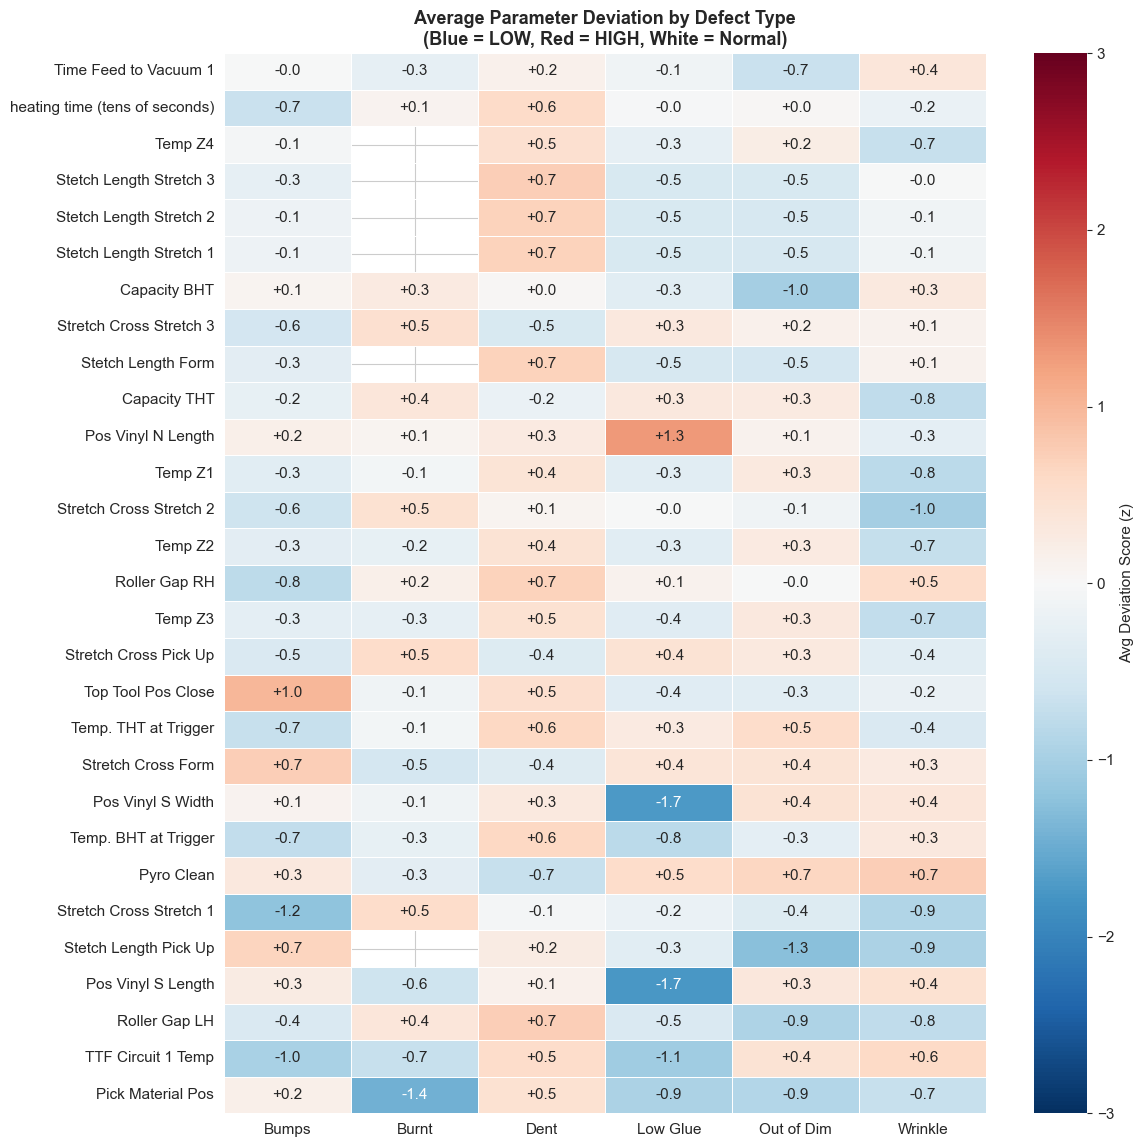

In [23]:
# Build pivot: defect x parameter → avg deviation score
major_defects = ['Low Glue/Read Thru/Impression', 'Wrinkle', 'Dent', 'Bumps / lumps',
                 'Out of dimension', 'Burnt Carpet / Vynil']

# Select parameters that have avg |z| > 0.5 for at least one defect
pivot = dev_df[dev_df['defect'].isin(major_defects)].pivot_table(
    index='parameter', columns='defect', values='deviation_score', aggfunc='mean')

# Filter to interesting parameters
max_abs = pivot.abs().max(axis=1)
interesting = max_abs[max_abs >= 0.5].index
pivot = pivot.loc[interesting]

# Sort by total deviation
pivot['total_abs'] = pivot.abs().sum(axis=1)
pivot = pivot.sort_values('total_abs', ascending=True)
pivot = pivot.drop(columns='total_abs')

# Rename columns for readability
short_defects = {
    'Low Glue/Read Thru/Impression': 'Low Glue',
    'Burnt Carpet / Vynil': 'Burnt',
    'Bumps / lumps': 'Bumps',
    'Out of dimension': 'Out of Dim',
}
pivot.columns = [short_defects.get(c, c) for c in pivot.columns]

fig, ax = plt.subplots(figsize=(12, max(8, len(pivot) * 0.4)))
sns.heatmap(pivot, annot=True, fmt='+.1f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, vmin=-3, vmax=3,
            cbar_kws={'label': 'Avg Deviation Score (z)'})
ax.set_title('Average Parameter Deviation by Defect Type\n(Blue = LOW, Red = HIGH, White = Normal)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('deviation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
def format_recommendation_text(part_row, min_abs_z=1.0, max_recs=10):
    """
    Generate a single text string summarizing all recommendations for a scrap part.
    This is what goes into the Excel 'Recommendation' column.
    """
    result = generate_recommendations(part_row, min_abs_z=min_abs_z, max_recs=max_recs)
    recs = result['recommendations']
    
    if not recs:
        return ('No significant parameter deviations detected. '
                'May be caused by factors outside tracked parameters '
                '(material quality, tool wear, etc.)')
    
    lines = []
    for section in SECTION_ORDER:
        sec_recs = [r for r in recs if r['section'] == section]
        if not sec_recs:
            continue
        for r in sec_recs:
            direction_word = 'HIGH' if r['direction'] == 'HIGH' else 'LOW'
            action = 'Reduce' if r['direction'] == 'HIGH' else 'Increase'
            sev = r['severity']
            name = r['display_name']
            z = r['deviation_score']
            lines.append(f'[{sev}] {name} running {direction_word} ({z:+.1f}) -> {action}')
    
    return '; '.join(lines)


# Build the export dataframe
scrap_for_export = df[df['is_process_scrap']].copy()

export_rows = []
for idx, row in scrap_for_export.iterrows():
    rec_text = format_recommendation_text(row)
    export_rows.append({
        'Part ID': row['ID'],
        'Part Description': row['part_desc'],
        'Built Time': row['built_time'],
        'Tool Number': int(row['Tool Number']),
        'Scrap Reason': row['description'],
        'Recommendation': rec_text,
    })

export_df = pd.DataFrame(export_rows)

# Save to Excel
output_file = 'Scrap_Recommendations_Report.xlsx'
with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    export_df.to_excel(writer, sheet_name='Scrap Recommendations', index=False)
    
    # Auto-adjust column widths for readability
    ws = writer.sheets['Scrap Recommendations']
    ws.column_dimensions['A'].width = 12   # Part ID
    ws.column_dimensions['B'].width = 25   # Part Description
    ws.column_dimensions['C'].width = 22   # Built Time
    ws.column_dimensions['D'].width = 12   # Tool Number
    ws.column_dimensions['E'].width = 35   # Scrap Reason
    ws.column_dimensions['F'].width = 120  # Recommendation

print(f'Exported {len(export_df)} scrap events to: {output_file}')
print(f'Columns: {list(export_df.columns)}')
print()
print('--- Preview (first 5 rows) ---')
print()
for _, row in export_df.head(5).iterrows():
    print(f"ID: {row['Part ID']}  |  {row['Scrap Reason']}  |  Tool {row['Tool Number']}")
    rec = row['Recommendation']
    # Print recommendation wrapped nicely
    parts = rec.split('; ')
    for p in parts:
        print(f'    {p}')
    print()

Exported 314 scrap events to: Scrap_Recommendations_Report.xlsx
Columns: ['Part ID', 'Part Description', 'Built Time', 'Tool Number', 'Scrap Reason', 'Recommendation']

--- Preview (first 5 rows) ---

ID: 8750646  |  Bumps / lumps  |  Tool 2
    [MODERATE] Roller Gap LH running LOW (-1.2) -> Increase
    [MODERATE] Roller Gap RH running LOW (-1.1) -> Increase
    [HIGH] Stretch Cross Stretch 3 running LOW (-2.1) -> Increase
    [HIGH] Stretch Cross Form running HIGH (+2.0) -> Reduce
    [MODERATE] Stretch Cross Pick Up running LOW (-1.9) -> Increase
    [MODERATE] Stretch Cross Stretch 1 running LOW (-1.9) -> Increase
    [MODERATE] Temp Z2 running LOW (-1.6) -> Increase
    [MODERATE] Temp Z1 running LOW (-1.6) -> Increase
    [MODERATE] Temp Z3 running LOW (-1.5) -> Increase
    [MODERATE] Top Heater Temp (THT) running LOW (-1.3) -> Increase

ID: 8750616  |  Bumps / lumps  |  Tool 2
    [MODERATE] Roller Gap LH running LOW (-1.2) -> Increase
    [MODERATE] Roller Gap RH running LOW (

---
## 12. Write Recommendations to Database (`dbo.VF_Prompt`)

This section connects to the IAC database and inserts recommendations into the `VF_Prompt` table.

| Column | What we write |
|---|---|
| `Prompt` | The recommendation text from the engine |
| `Processed` | Part ID + Tool Number (e.g., `8716551_T1`) as a unique identifier |
| `DateInsert` | Auto-populated by DB or set to current timestamp |

We first test with a **single row** to confirm connectivity and measure write latency.

In [ ]:
# ── Database Connection Setup ──
import plantbrain.io as import_lib
from src.configurations import configReaderObj
import time

connector = import_lib.getConnection('mssql')
status, iacdbCreds = configReaderObj.get('sqldbiac')
iacConnection = connector(iacdbCreds)

print(f'Connection status: {status}')

# Verify table exists and check current state
current = iacConnection.read('dbo.VF_Prompt')
print(f'Current rows in VF_Prompt: {len(current)}')
display(current.head())

In [ ]:
# ── TEST: Write a single recommendation to verify connectivity ──

# Pick one real scrap event and generate its recommendation
test_row = df[df['is_process_scrap']].iloc[0]
test_rec = format_recommendation_text(test_row)
test_id = f"{int(test_row['ID'])}_T{int(test_row['Tool Number'])}"

print(f'Test Part ID:       {test_row["ID"]}')
print(f'Test Defect:        {test_row["description"]}')
print(f'Processed value:    {test_id}')
print(f'Recommendation:     {test_rec[:120]}...')
print()

# Build the test insert dataframe
test_insert = pd.DataFrame([{
    'Prompt': test_rec,
    'Processed': test_id
}])

# Time the write
start = time.time()
iacConnection.write(test_insert, 'dbo.VF_Prompt', if_exists='append')
elapsed = time.time() - start

print(f'Single row write time: {elapsed:.3f} seconds')
print()

# Verify it was written
verify = iacConnection.read('dbo.VF_Prompt')
print(f'Rows after insert: {len(verify)}')
display(verify.tail(3))

In [ ]:
# ── BULK WRITE: All scrap recommendations ──
# Only run this once you've confirmed the test write above works.

scrap_for_db = df[df['is_process_scrap']].copy()

db_rows = []
for idx, row in scrap_for_db.iterrows():
    rec_text = format_recommendation_text(row)
    part_tool_id = f"{int(row['ID'])}_T{int(row['Tool Number'])}"
    db_rows.append({
        'Prompt': rec_text,
        'Processed': part_tool_id
    })

db_df = pd.DataFrame(db_rows)

print(f'Prepared {len(db_df)} rows for insert')
print(f'Sample Processed values: {db_df["Processed"].head(5).tolist()}')
print(f'Avg recommendation length: {db_df["Prompt"].str.len().mean():.0f} chars')
print()

# Time the bulk write
start = time.time()
iacConnection.write(db_df, 'dbo.VF_Prompt', if_exists='append')
elapsed = time.time() - start

print(f'Bulk write time: {elapsed:.2f} seconds for {len(db_df)} rows')
print(f'Average per row:  {elapsed/len(db_df)*1000:.1f} ms')
print()

# Final verification
final = iacConnection.read('dbo.VF_Prompt')
print(f'Total rows in VF_Prompt after bulk insert: {len(final)}')
display(final.tail(5))